# Normalization of Deviance -- When Exceptions Become the Rule

Diane Vaughan coined "normalization of deviance" studying the Challenger disaster:
repeated boundary violations that produce no immediate consequence get reinterpreted
as acceptable. The O-ring erosion was a known anomaly, but because previous flights
survived it, the anomaly became the new baseline.

The same pattern plays out in security every day. Firewall exceptions that accumulate.
"Temporary" admin access that becomes permanent. Alert thresholds raised to reduce noise
until the alerts no longer detect anything meaningful. Each individual decision is locally
rational -- the system kept working, so the deviation must be tolerable.

This notebook simulates the drift, quantifies the hidden risk it creates, and shows
why resetting to policy -- though politically expensive -- is almost always cheaper
than the alternative.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from decision_security.synth import make_rng, sample
from decision_security.montecarlo import simulate_aggregate_losses, make_lognormal_severity

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"

## 1. The Drift

Consider a firewall exception policy: at most 5 active exceptions at any time.
Each week there is a 40% chance a new exception is requested (and granted -- because
it is "just one more") and a 10% chance that an existing exception is reviewed and
closed. For the first 30 weeks, no security incident occurs. The count drifts upward,
and because nothing bad happens, the drift is reinterpreted as normal.

> *"The unexpected becomes expected, and the expected becomes accepted."*
> -- paraphrasing Vaughan (1996)

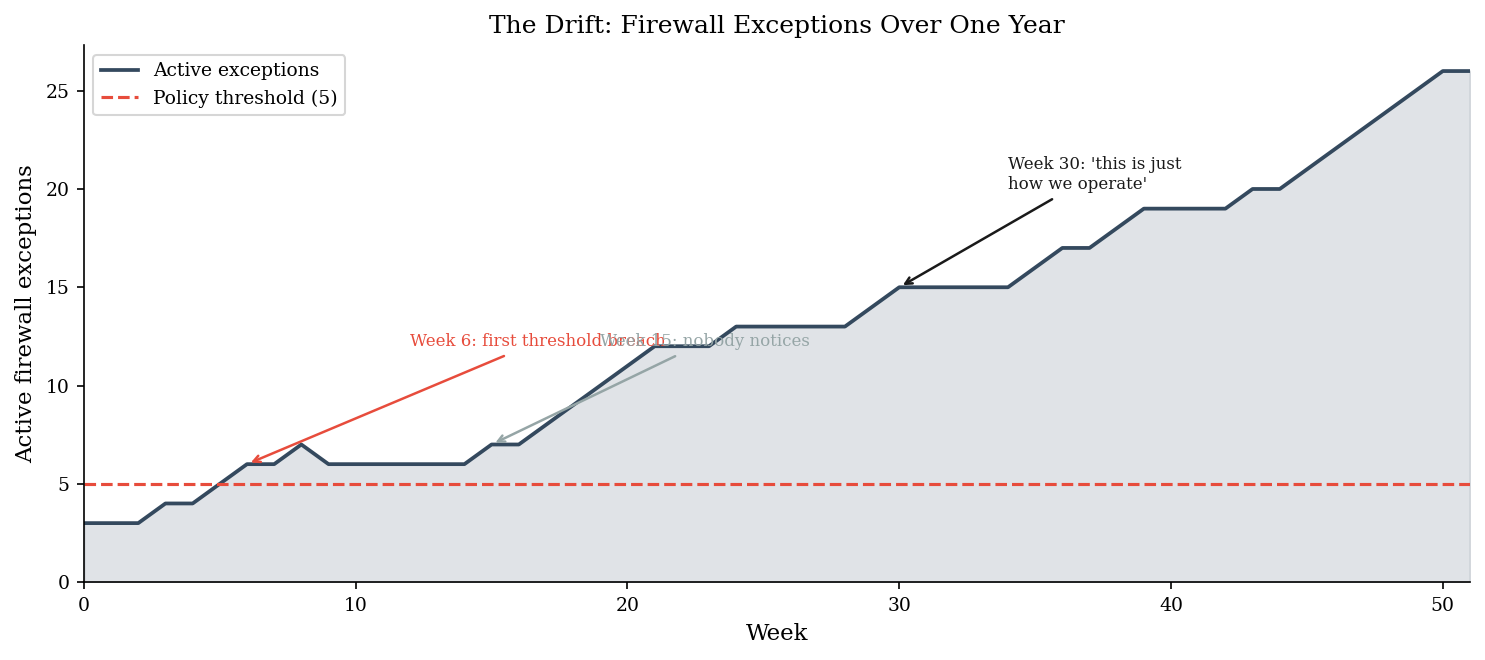


Policy limit: 5
Exceptions at week 26: 13
Exceptions at week 52: 26
Peak: 26 (week 50)


In [2]:
n_weeks = 52
policy_max = 5
p_new = 0.55        # probability of a new exception request per week
p_close = 0.08      # probability any existing exception is reviewed & closed

rng_drift = make_rng(42)
exceptions = np.zeros(n_weeks, dtype=int)
exceptions[0] = 3  # start below the policy limit

for w in range(1, n_weeks):
    current = exceptions[w - 1]
    # new exception requested?
    added = 1 if rng_drift.random() < p_new else 0
    # small chance one exception gets reviewed and closed
    closed = 1 if (current > 0 and rng_drift.random() < p_close) else 0
    exceptions[w] = max(0, current + added - closed)

weeks = np.arange(n_weeks)

# find key moments for annotations
first_breach_week = int(np.argmax(exceptions > policy_max))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(weeks, 0, exceptions, alpha=0.15, color=DARK_BG)
ax.plot(weeks, exceptions, color=DARK_BG, linewidth=1.8, label="Active exceptions")
ax.axhline(policy_max, color=ACCENT, linestyle="--", linewidth=1.5,
           label=f"Policy threshold ({policy_max})")

# Annotations
ax.annotate(f"Week {first_breach_week}: first threshold breach",
            xy=(first_breach_week, exceptions[first_breach_week]),
            xytext=(first_breach_week + 6, exceptions[first_breach_week] + 6),
            arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.2),
            fontsize=8, color=ACCENT)
ax.annotate("Week 15: nobody notices",
            xy=(15, exceptions[15]),
            xytext=(19, exceptions[15] + 5),
            arrowprops=dict(arrowstyle="->", color=LIGHT_GRAY, lw=1.2),
            fontsize=8, color=LIGHT_GRAY)
ax.annotate("Week 30: 'this is just\nhow we operate'",
            xy=(30, exceptions[30]),
            xytext=(34, exceptions[30] + 5),
            arrowprops=dict(arrowstyle="->", color=PRIMARY, lw=1.2),
            fontsize=8, color=PRIMARY)

ax.set_xlabel("Week")
ax.set_ylabel("Active firewall exceptions")
ax.set_title("The Drift: Firewall Exceptions Over One Year")
ax.legend(loc="upper left")
ax.set_xlim(0, n_weeks - 1)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

print(f"\nPolicy limit: {policy_max}")
print(f"Exceptions at week 26: {exceptions[26]}")
print(f"Exceptions at week 52: {exceptions[-1]}")
print(f"Peak: {exceptions.max()} (week {exceptions.argmax()})")

## 2. Near Misses as Normalization Fuel

The reason normalization of deviance persists is that bad outcomes are probabilistic,
not deterministic. Each week without an incident reinforces the belief that the current
state is safe. But the *probability* of an incident is climbing -- we just haven't
sampled the bad outcome yet.

Near misses -- weeks where the true probability was high but nothing happened --
are the most dangerous data points. They teach the organization exactly the wrong lesson:
that the current level of deviance is tolerable.

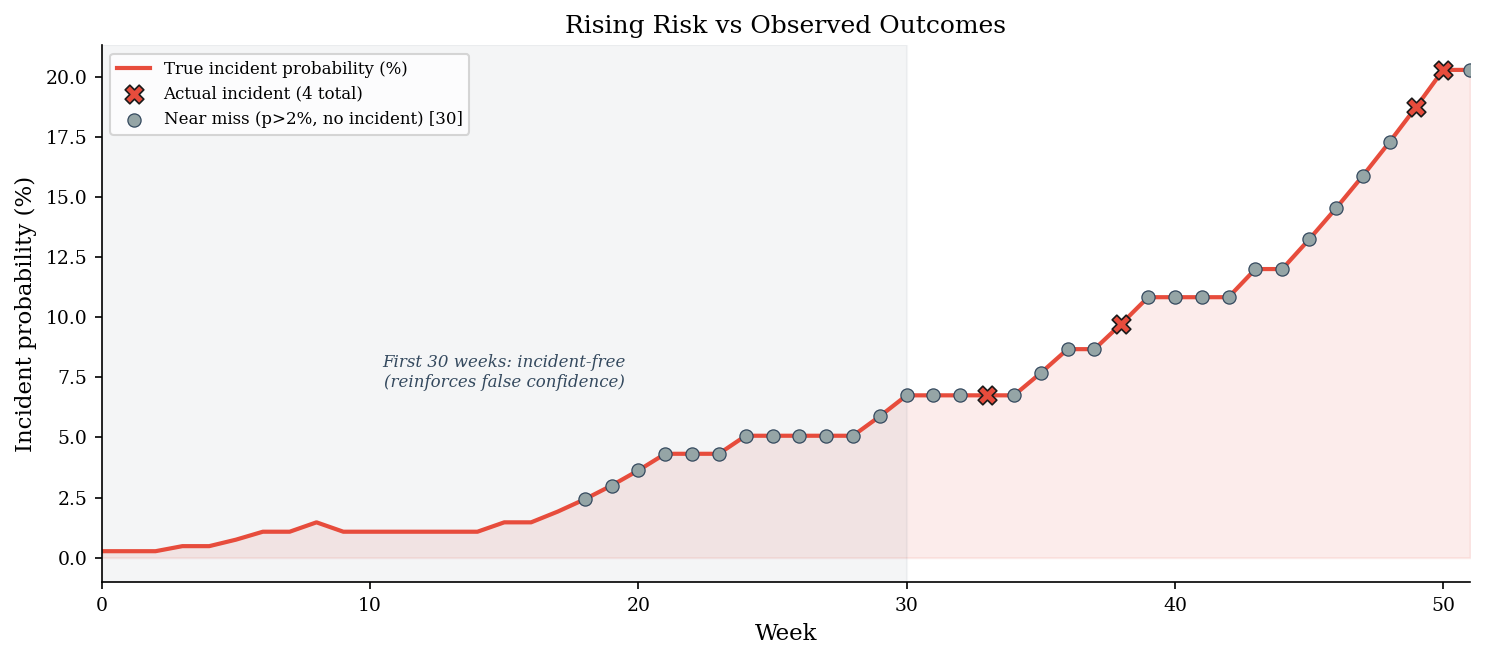

Weeks with p(incident) > 2%: 34
Weeks with p(incident) > 5%: 28
Actual incidents: 4
Near misses (p>2%, no incident): 30

Absence of incidents is not evidence of safety --
it is sampling from a distribution.


In [3]:
# Incident probability grows quadratically with active exceptions
p_incident = 0.0003 * exceptions**2

# Simulate whether an incident actually occurs each week
rng_incidents = make_rng(29)
incident_rolls = rng_incidents.random(n_weeks)
incidents = incident_rolls < p_incident

fig, ax = plt.subplots(figsize=(10, 4.5))

# True probability curve
ax.plot(weeks, p_incident * 100, color=ACCENT, linewidth=2,
        label="True incident probability (%)")
ax.fill_between(weeks, 0, p_incident * 100, alpha=0.1, color=ACCENT)

# Mark actual incidents
incident_weeks = weeks[incidents]
if len(incident_weeks) > 0:
    ax.scatter(incident_weeks, p_incident[incidents] * 100,
               color=ACCENT, s=80, zorder=5, marker="X",
               edgecolors=PRIMARY, linewidth=0.8,
               label=f"Actual incident ({len(incident_weeks)} total)")

# Mark near misses: weeks where p > 2% but no incident
near_miss = (p_incident > 0.02) & ~incidents
near_miss_weeks = weeks[near_miss]
if len(near_miss_weeks) > 0:
    ax.scatter(near_miss_weeks, p_incident[near_miss] * 100,
               color=LIGHT_GRAY, s=40, zorder=4, marker="o",
               edgecolors=DARK_BG, linewidth=0.6,
               label=f"Near miss (p>2%, no incident) [{len(near_miss_weeks)}]")

# The incident-free zone
ax.axvspan(0, 30, alpha=0.05, color=DARK_BG)
ax.text(15, max(p_incident * 100) * 0.35,
        "First 30 weeks: incident-free\n(reinforces false confidence)",
        ha="center", fontsize=8, color=DARK_BG, style="italic")

ax.set_xlabel("Week")
ax.set_ylabel("Incident probability (%)")
ax.set_title("Rising Risk vs Observed Outcomes")
ax.legend(loc="upper left", fontsize=8)
ax.set_xlim(0, n_weeks - 1)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"Weeks with p(incident) > 2%: {(p_incident > 0.02).sum()}")
print(f"Weeks with p(incident) > 5%: {(p_incident > 0.05).sum()}")
print(f"Actual incidents: {incidents.sum()}")
print(f"Near misses (p>2%, no incident): {near_miss.sum()}")
print(f"\nAbsence of incidents is not evidence of safety --")
print(f"it is sampling from a distribution.")

## 3. Threshold Erosion

A SOC team sets an alert threshold at 100 events/day. The threshold is reasonable
at first, but alert fatigue creeps in. Each month, the team raises the threshold by
10% to reduce noise. After 12 months, the threshold has nearly tripled.

The problem: real attack signals do not grow with the threshold. As the threshold
rises, the fraction of actual attacks that fall below it -- the detection blindspot --
grows silently.

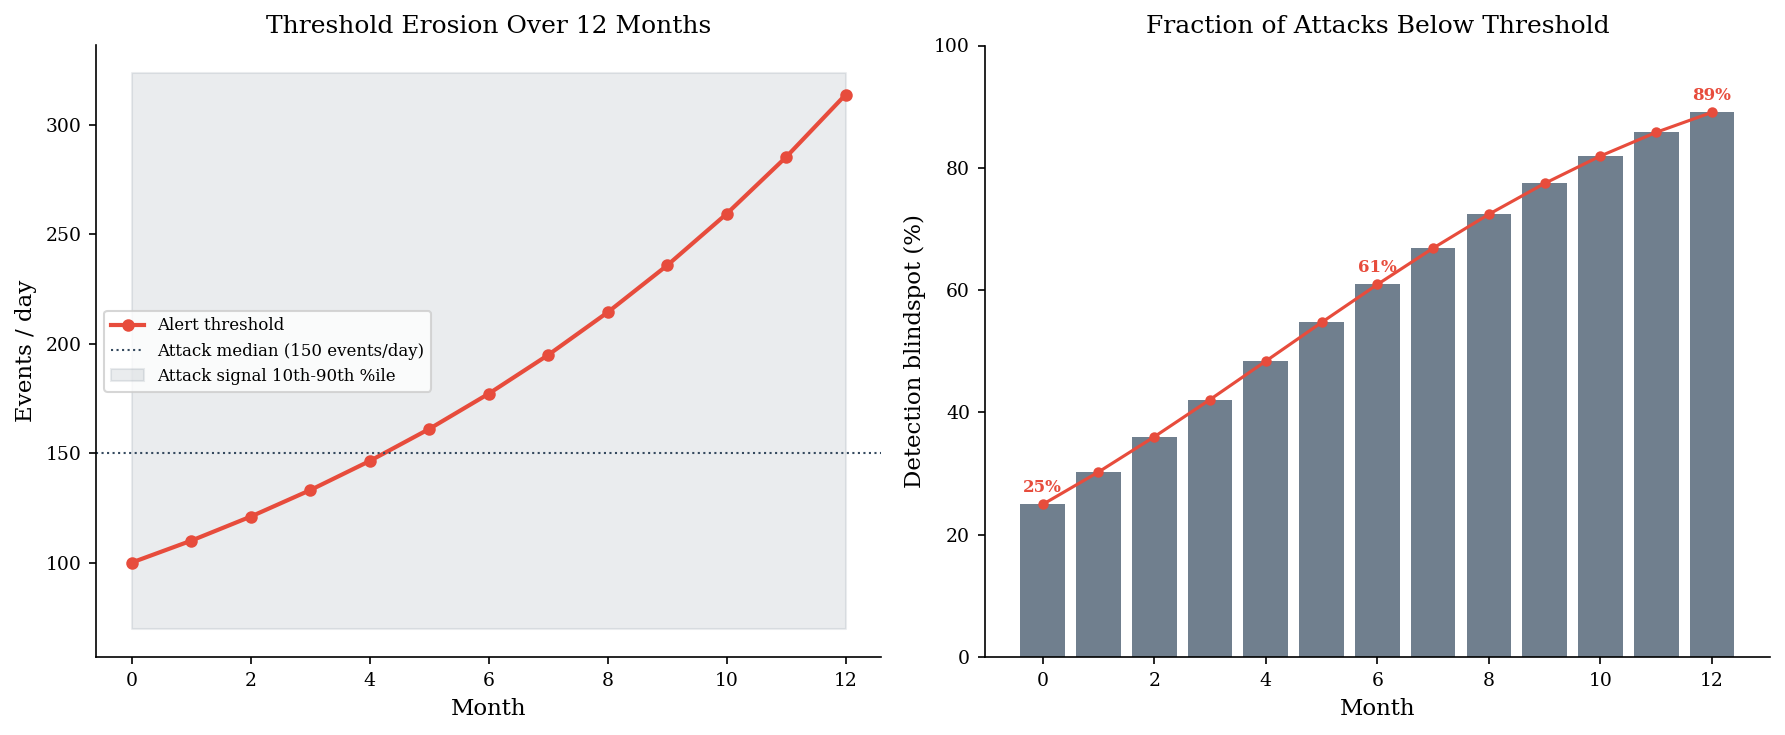

Month 0: threshold = 100, blindspot = 25.0%
Month 6: threshold = 177, blindspot = 60.9%
Month 12: threshold = 314, blindspot = 89.1%

The threshold nearly tripled. The blindspot grew from 25% to 89%.


In [4]:
from scipy import stats

n_months = 12
initial_threshold = 100
monthly_increase = 0.10  # 10% raise each month

months = np.arange(n_months + 1)  # 0 through 12
thresholds = initial_threshold * (1 + monthly_increase) ** months

# Attack signal distribution: lognormal with median=150 events/day
# median of lognormal = exp(mu), so mu = ln(150)
attack_mu = np.log(150)
attack_sigma = 0.6  # moderate spread
attack_dist = stats.lognorm(s=attack_sigma, scale=np.exp(attack_mu))

# Blindspot: fraction of attack distribution below threshold
blindspot = np.array([attack_dist.cdf(t) for t in thresholds])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: threshold over time with attack distribution context
ax = axes[0]
ax.plot(months, thresholds, "o-", color=ACCENT, linewidth=2,
        markersize=5, label="Alert threshold")
ax.axhline(150, color=DARK_BG, linestyle=":", linewidth=1,
           label="Attack median (150 events/day)")
ax.fill_between(months, attack_dist.ppf(0.1), attack_dist.ppf(0.9),
                alpha=0.1, color=DARK_BG, label="Attack signal 10th-90th %ile")
ax.set_xlabel("Month")
ax.set_ylabel("Events / day")
ax.set_title("Threshold Erosion Over 12 Months")
ax.legend(fontsize=8)

# Right: blindspot fraction over time
ax = axes[1]
ax.bar(months, blindspot * 100, color=DARK_BG, alpha=0.7, edgecolor="none")
ax.plot(months, blindspot * 100, "o-", color=ACCENT, linewidth=1.5, markersize=4)
for i in [0, 6, 12]:
    ax.text(i, blindspot[i] * 100 + 2, f"{blindspot[i]:.0%}",
            ha="center", fontsize=8, color=ACCENT, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Detection blindspot (%)")
ax.set_title("Fraction of Attacks Below Threshold")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f"Month 0: threshold = {thresholds[0]:.0f}, blindspot = {blindspot[0]:.1%}")
print(f"Month 6: threshold = {thresholds[6]:.0f}, blindspot = {blindspot[6]:.1%}")
print(f"Month 12: threshold = {thresholds[12]:.0f}, blindspot = {blindspot[12]:.1%}")
print(f"\nThe threshold nearly tripled. The blindspot grew from"
      f" {blindspot[0]:.0%} to {blindspot[12]:.0%}.")

## 4. The Cost of Resetting

Resetting to policy is politically expensive. Re-approving exceptions means
paperwork, disruption, and difficult conversations. So the reset keeps getting
deferred. But deferred resets compound risk.

Here we model the decision: reset all firewall exceptions back to 5 (at a known
cost of ~\$50K in disruption) versus continue operating with 20 active exceptions
(with a probabilistic cost from breach exposure). We use a compound Poisson model
where frequency scales quadratically with exception count.

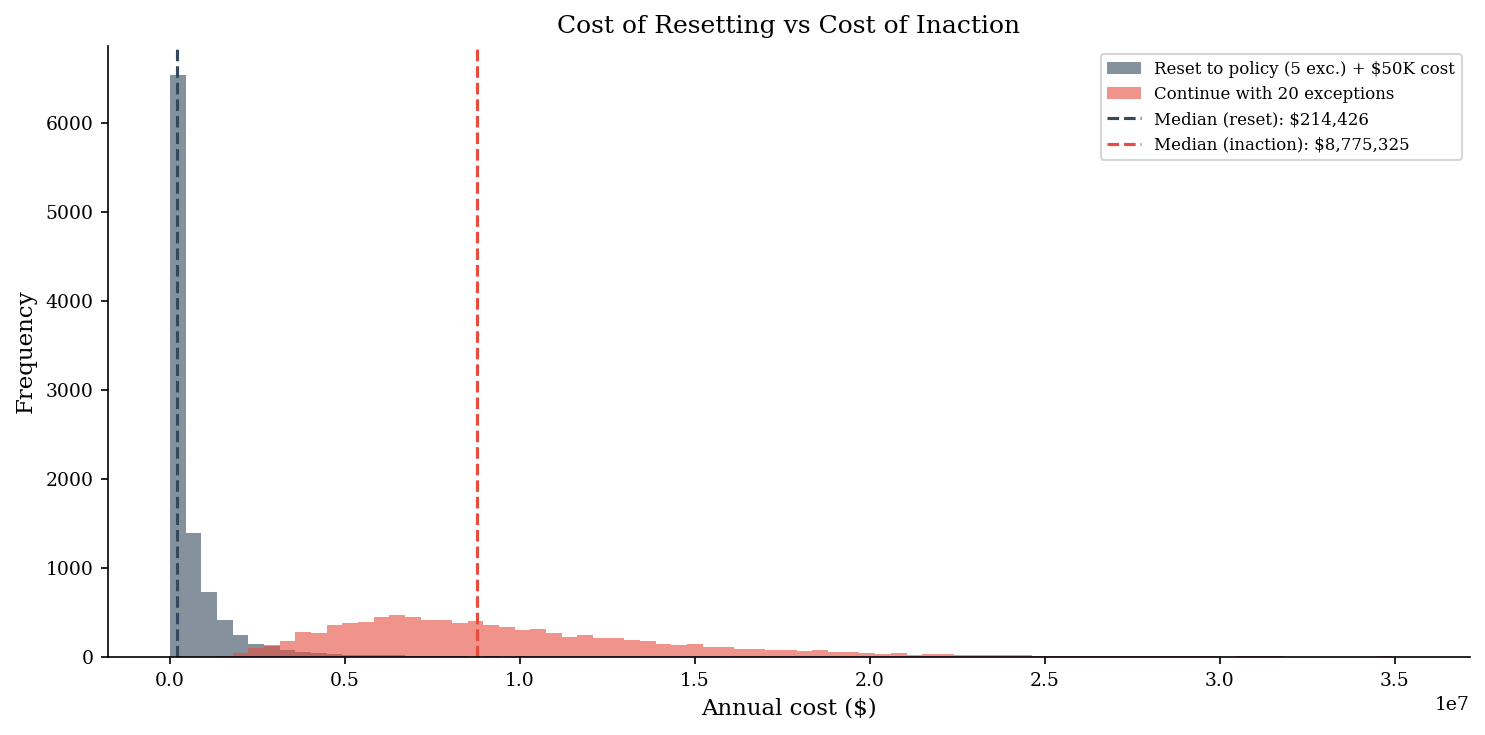

Annual frequency at 5 exceptions:  lambda = 1.3
Annual frequency at 20 exceptions: lambda = 20.8

Metric                   Reset + $50K         Inaction
----------------------------------------------------
Mean                 $       701,706 $    10,376,184
Median (p50)         $       214,426 $     8,775,325
p90                  $     1,672,325 $    17,580,477
p95                  $     2,748,494 $    21,738,833

Inaction costs more than resetting in 99% of simulations.


In [5]:
n_sims = 10_000
reset_cost = 50_000  # known disruption cost

# Severity: lognormal breach losses
# meanlog=12 ~ median around $160K, sdlog=1.5 gives heavy right tail
sev = make_lognormal_severity(meanlog=12, sdlog=1.5)

# Annual frequency: lambda = 0.001 * exceptions^2 * 52 weeks
# At 5 exceptions:  lambda = 0.001 * 25 * 52 = 1.3
# At 20 exceptions: lambda = 0.001 * 400 * 52 = 20.8
lam_5 = 0.001 * 5**2 * 52
lam_20 = 0.001 * 20**2 * 52

rng_reset = make_rng(42)
losses_5 = simulate_aggregate_losses(n_sims, lam_5, sev, rng=make_rng(42))
losses_20 = simulate_aggregate_losses(n_sims, lam_20, sev, rng=make_rng(43))

# Total cost of resetting = reset_cost + residual losses at 5 exceptions
total_reset = reset_cost + losses_5
# Total cost of inaction = losses at 20 exceptions (no reset cost)
total_inaction = losses_20

fig, ax = plt.subplots(figsize=(10, 5))

bins = np.linspace(0, np.percentile(total_inaction, 99), 80)
ax.hist(total_reset, bins=bins, alpha=0.6, color=DARK_BG,
        label=f"Reset to policy (5 exc.) + $50K cost", edgecolor="none")
ax.hist(total_inaction, bins=bins, alpha=0.6, color=ACCENT,
        label=f"Continue with 20 exceptions", edgecolor="none")

# Mark medians
med_reset = np.median(total_reset)
med_inaction = np.median(total_inaction)
ax.axvline(med_reset, color=DARK_BG, linestyle="--", linewidth=1.5,
           label=f"Median (reset): ${med_reset:,.0f}")
ax.axvline(med_inaction, color=ACCENT, linestyle="--", linewidth=1.5,
           label=f"Median (inaction): ${med_inaction:,.0f}")

ax.set_xlabel("Annual cost ($)")
ax.set_ylabel("Frequency")
ax.set_title("Cost of Resetting vs Cost of Inaction")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Annual frequency at 5 exceptions:  lambda = {lam_5:.1f}")
print(f"Annual frequency at 20 exceptions: lambda = {lam_20:.1f}")
print(f"")
print(f"{'Metric':<20} {'Reset + $50K':>16} {'Inaction':>16}")
print(f"{'-'*52}")
for label, q in [("Mean", None), ("Median (p50)", 0.5), ("p90", 0.9), ("p95", 0.95)]:
    if q is None:
        v_r, v_i = total_reset.mean(), total_inaction.mean()
    else:
        v_r = np.quantile(total_reset, q)
        v_i = np.quantile(total_inaction, q)
    print(f"{label:<20} ${v_r:>14,.0f} ${v_i:>14,.0f}")

pct_inaction_worse = (total_inaction > total_reset).mean()
print(f"\nInaction costs more than resetting in {pct_inaction_worse:.0%} of simulations.")

## 5. Organizational Indicators

Normalization of deviance is a cultural phenomenon. It shows up in the language
people use, the decisions they defer, and the way they frame past outcomes.
Below is a diagnostic scorecard: eight warning signs that an organization is
deep in the drift. Each is scored on a 1-5 scale (1 = not present, 5 = pervasive).

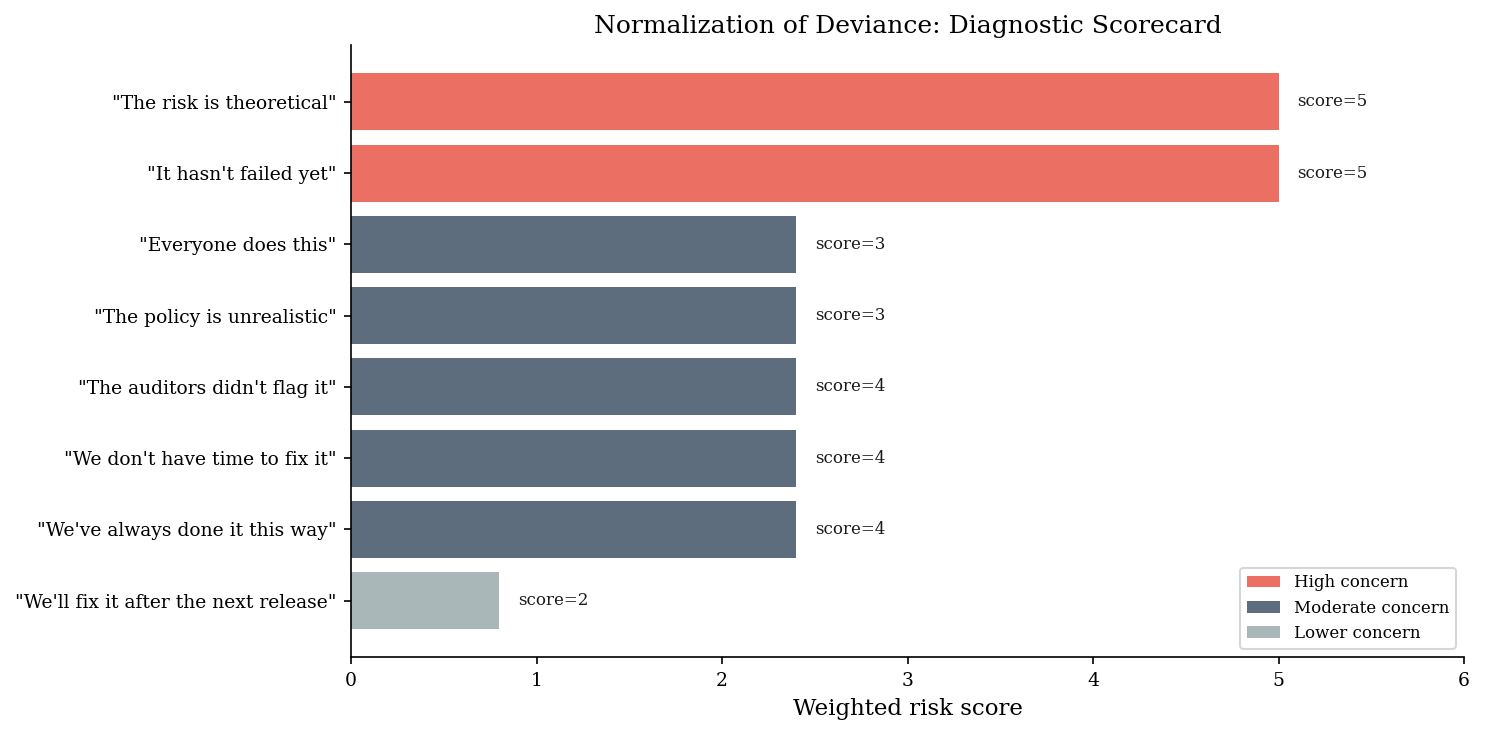

Total weighted score: 22.8 / 29.0
Normalization index: 79%


In [6]:
indicators = [
    '"We\'ve always done it this way"',
    '"It hasn\'t failed yet"',
    '"The policy is unrealistic"',
    '"We don\'t have time to fix it"',
    '"Everyone does this"',
    '"The risk is theoretical"',
    '"We\'ll fix it after the next release"',
    '"The auditors didn\'t flag it"',
]

risk_weights = np.array([3, 5, 4, 3, 4, 5, 2, 3], dtype=float)
risk_weights /= risk_weights.max()  # normalize to 0-1 for display

# Hypothetical organization scores (1-5 scale)
org_scores = np.array([4, 5, 3, 4, 3, 5, 2, 4], dtype=float)

# Weighted risk = score * weight
weighted = org_scores * risk_weights

# Sort by weighted score for display
sort_idx = np.argsort(weighted)
sorted_indicators = [indicators[i] for i in sort_idx]
sorted_weighted = weighted[sort_idx]
sorted_scores = org_scores[sort_idx]

fig, ax = plt.subplots(figsize=(10, 5))

colors = [ACCENT if w > 3.5 else DARK_BG if w > 2 else LIGHT_GRAY
          for w in sorted_weighted]
bars = ax.barh(range(len(sorted_indicators)), sorted_weighted,
               color=colors, edgecolor="none", alpha=0.8)

# Add score annotations
for i, (w, s) in enumerate(zip(sorted_weighted, sorted_scores)):
    ax.text(w + 0.1, i, f"score={s:.0f}", va="center", fontsize=8, color=PRIMARY)

ax.set_yticks(range(len(sorted_indicators)))
ax.set_yticklabels(sorted_indicators, fontsize=9)
ax.set_xlabel("Weighted risk score")
ax.set_title("Normalization of Deviance: Diagnostic Scorecard")
ax.set_xlim(0, 6)

# Color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=ACCENT, alpha=0.8, label="High concern"),
    Patch(facecolor=DARK_BG, alpha=0.8, label="Moderate concern"),
    Patch(facecolor=LIGHT_GRAY, alpha=0.8, label="Lower concern"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

total_score = weighted.sum()
max_possible = (5 * risk_weights).sum()
print(f"Total weighted score: {total_score:.1f} / {max_possible:.1f}")
print(f"Normalization index: {total_score / max_possible:.0%}")

## 6. Pitfalls

**Near misses reinforce normalization instead of warning.** Every week the system
operates above policy without an incident is a data point that teaches the
organization the wrong lesson. Near misses should trigger investigation; instead
they build confidence.

**Success teaches the wrong lesson.** The absence of failure is not the same as
the presence of safety. A system that has never failed may simply be a system
that has not yet been tested by the right conditions.

**Resets are politically expensive, so they get deferred.** The known, visible
cost of resetting (disruption, rework, uncomfortable conversations) is weighed
against the unknown, probabilistic cost of continuing. Humans reliably choose
the certain small cost over the uncertain large one -- even when the expected
value clearly favors resetting.

**The drift is invisible to those inside it.** Each individual step is small.
Nobody decided to have 20 firewall exceptions. It happened one exception at a
time, each one locally reasonable.

**Dissenting voices get labeled as alarmist.** When someone raises the concern,
the response is: "We've been operating this way for months and nothing has
happened." The data (no incidents) appears to support the status quo. The
dissenter cannot point to a concrete failure -- only to a probability.

> *"Near misses and small incidents should not be regarded or normalized as
> they can be indicators of much larger problems."*

---

*Part 2.2 of the Security Decision Science notebook series.*